# HDT 2 - Visión Por Computadora

Autores:

- Nelson García
- Joaquín Puente
- Diego Linares

# Task 1 - Análisis

# Task 2 – Ingeniería de Dimensiones

# Task 3 – Criterio de Diseño

# Task 4 – Implementación Práctica



In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:

def manual_convolution(image, kernel, stride=1, padding=0):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("image y kernel deben ser matrices 2D.")
    if kernel.shape[0] != kernel.shape[1]:
        raise ValueError("El kernel debe ser cuadrado (N x N).")
    if stride <= 0:
        raise ValueError("stride debe ser >= 1.")
    if padding < 0:
        raise ValueError("padding debe ser >= 0.")

    H, W = image.shape
    N = kernel.shape[0]

    padded = np.pad(image, pad_width=padding, mode="constant", constant_values=0)
    H_p, W_p = padded.shape

    H_out = (H_p - N) // stride + 1
    W_out = (W_p - N) // stride + 1
    if H_out <= 0 or W_out <= 0:
        raise ValueError("Kernel/padding/stride incompatibles: salida no válida.")

    out = np.zeros((H_out, W_out), dtype=float)

    out_i = 0
    for i in range(0, H_p - N + 1, stride):
        out_j = 0
        for j in range(0, W_p - N + 1, stride):
            window = padded[i:i+N, j:j+N]
            out[out_i, out_j] = np.sum(window * kernel)
            out_j += 1
        out_i += 1

    return out

def normalize_for_display(x):
    """Escala a 0..255 para visualizar (sin cambiar el cálculo real)."""
    x = x.astype(np.float32)
    mn, mx = x.min(), x.max()
    if mx - mn < 1e-8:
        return np.zeros_like(x, dtype=np.uint8)
    x = (x - mn) * (255.0 / (mx - mn))
    return x.astype(np.uint8)


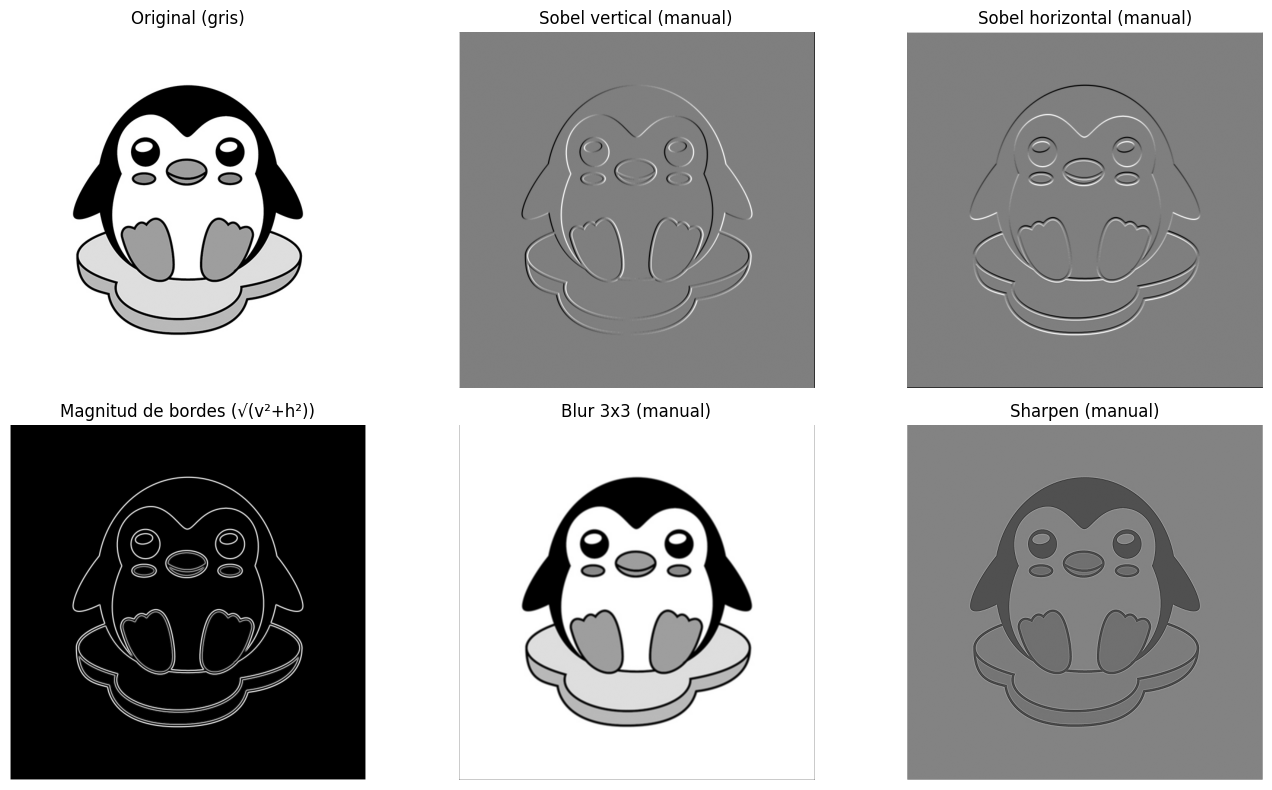

In [7]:

# Cargar imagen 
img_bgr = cv2.imread("pinguino.jpg")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Definir kernels 
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

sobel_horizontal = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=float)

blur_3x3 = (1/9) * np.ones((3, 3), dtype=float)

sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=float)

# Aplicar convoluciones manuales
edges_v = manual_convolution(img_gray, sobel_vertical, stride=1, padding=1)
edges_h = manual_convolution(img_gray, sobel_horizontal, stride=1, padding=1)
blurred = manual_convolution(img_gray, blur_3x3, stride=1, padding=1)
sharpened = manual_convolution(img_gray, sharpen, stride=1, padding=1)

edge_magnitude = np.sqrt(edges_v**2 + edges_h**2)

# Preparar para mostrar 
disp_original = img_gray
disp_edges_v = normalize_for_display(edges_v)
disp_edges_h = normalize_for_display(edges_h)
disp_blur = normalize_for_display(blurred)
disp_sharp = normalize_for_display(sharpened)
disp_mag = normalize_for_display(edge_magnitude)

# Mostrar resultados
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.ravel()

axs[0].imshow(disp_original, cmap="gray")
axs[0].set_title("Original (gris)")
axs[0].axis("off")

axs[1].imshow(disp_edges_v, cmap="gray")
axs[1].set_title("Sobel vertical (manual)")
axs[1].axis("off")

axs[2].imshow(disp_edges_h, cmap="gray")
axs[2].set_title("Sobel horizontal (manual)")
axs[2].axis("off")

axs[3].imshow(disp_mag, cmap="gray")
axs[3].set_title("Magnitud de bordes (√(v²+h²))")
axs[3].axis("off")

axs[4].imshow(disp_blur, cmap="gray")
axs[4].set_title("Blur 3x3 (manual)")
axs[4].axis("off")

axs[5].imshow(disp_sharp, cmap="gray")
axs[5].set_title("Sharpen (manual)")
axs[5].axis("off")

plt.tight_layout()
plt.show()